# Sideband Interactions and Dressed Energy Levels

This notebook constructs the core three-mode `cqed_sim` model directly with `DispersiveReadoutTransmonStorageModel` and uses the library spectrum API to inspect the underlying dressed Hamiltonian.

Two conventions are important throughout:

- The energy-level plot is generated from the **lab-frame** static Hamiltonian so the dressed ladder is easy to interpret.
- The driven sideband scans use **rotating-frame** transition helpers because `Pulse.carrier` follows the runtime convention `carrier = -omega_transition(frame)`.

The reported spectrum is always shifted so the bare vacuum state has zero energy.

In [1]:
from __future__ import annotations

import json
import sys
from pathlib import Path

import matplotlib.pyplot as plt
import numpy as np
import qutip as qt

REPO_ROOT = Path.cwd().resolve()
if not (REPO_ROOT / "cqed_sim").exists():
    if (REPO_ROOT.parent / "cqed_sim").exists():
        REPO_ROOT = REPO_ROOT.parent
    else:
        raise RuntimeError("Run this notebook from the repository root or the examples/ directory.")
if str(REPO_ROOT) not in sys.path:
    sys.path.insert(0, str(REPO_ROOT))

from cqed_sim import (
    DispersiveReadoutTransmonStorageModel,
    FrameSpec,
    NoiseSpec,
    Pulse,
    SequenceCompiler,
    SidebandDriveSpec,
    SimulationConfig,
    TransmonTransitionDriveSpec,
    carrier_for_transition_frequency,
    simulate_sequence,
)
from cqed_sim.plotting import plot_energy_levels
from cqed_sim.sim import pure_dephasing_time_from_t1_t2
from examples.workflows.sequential_sideband_reset import SequentialSidebandResetCalibration, run_sequential_sideband_reset
from physics_and_conventions.conventions import from_internal_units, to_internal_units

plt.rcParams["figure.figsize"] = (7.5, 4.5)
plt.rcParams["axes.grid"] = True

PULSE_DT_S = 0.25e-9
RINGDOWN_DT_S = 4.0e-9
OUTPUT_DIR = REPO_ROOT / "examples" / "outputs" / "sideband_interactions"
OUTPUT_DIR.mkdir(parents=True, exist_ok=True)

MODEL_PARAMS_HZ = {
    "omega_r": 8596222556.078796,
    "omega_q": 6150358764.4830475,
    "omega_s": 5240932800.0,
    "alpha": -255669694.5244608,
    "chi_s": -2840421.0,
    "chi_r": -3.0e6,
}
REFERENCE_FREQUENCIES_HZ = {
    "storage_gf_sideband": 6803533628.0,
}
NOISE_PARAMS = {
    "readout_kappa_hz": 4156000.0,
    "storage_t1_s": 250.0e-6,
    "storage_t2_ramsey_s": 150.0e-6,
}

MODEL = DispersiveReadoutTransmonStorageModel(
    omega_s=to_internal_units(MODEL_PARAMS_HZ["omega_s"]),
    omega_r=to_internal_units(MODEL_PARAMS_HZ["omega_r"]),
    omega_q=to_internal_units(MODEL_PARAMS_HZ["omega_q"]),
    alpha=to_internal_units(MODEL_PARAMS_HZ["alpha"]),
    chi_s=to_internal_units(MODEL_PARAMS_HZ["chi_s"]),
    chi_r=to_internal_units(MODEL_PARAMS_HZ["chi_r"]),
    n_storage=6,
    n_readout=4,
    n_tr=3,
)
FRAME = FrameSpec(
    omega_c_frame=MODEL.omega_s,
    omega_q_frame=MODEL.omega_q,
    omega_r_frame=MODEL.omega_r,
)
tphi_storage_s = pure_dephasing_time_from_t1_t2(
    t1_s=NOISE_PARAMS["storage_t1_s"],
    t2_s=NOISE_PARAMS["storage_t2_ramsey_s"],
)
NOISE = NoiseSpec(
    kappa_storage=None if NOISE_PARAMS["storage_t1_s"] <= 0.0 else 1.0 / NOISE_PARAMS["storage_t1_s"],
    kappa_readout=NOISE_PARAMS["readout_kappa_hz"],
    tphi_storage=tphi_storage_s,
)

CALIBRATION = SequentialSidebandResetCalibration(
    storage_sideband_rate_hz=8.0e6,
    readout_sideband_rate_hz=10.0e6,
    ef_rate_hz=12.0e6,
    ringdown_multiple=3.0,
)

def _square_envelope(t_rel: np.ndarray) -> np.ndarray:
    return np.ones_like(t_rel, dtype=np.complex128)


def run_drive_pulse(
    initial_state: qt.Qobj,
    *,
    drive_target: TransmonTransitionDriveSpec | SidebandDriveSpec,
    frequency_rad_s: float,
    amplitude_rad_s: float,
    duration_s: float,
    channel: str,
    noise=NOISE,
    dt_s: float = PULSE_DT_S,
    store_states: bool = False,
):
    pulse = Pulse(
        channel,
        0.0,
        float(duration_s),
        _square_envelope,
        amp=float(amplitude_rad_s),
        carrier=carrier_for_transition_frequency(float(frequency_rad_s)),
    )
    compiled = SequenceCompiler(dt=dt_s).compile([pulse], t_end=float(duration_s))
    result = simulate_sequence(
        MODEL,
        compiled,
        initial_state,
        {channel: drive_target},
        SimulationConfig(frame=FRAME, store_states=store_states, max_step=dt_s),
        noise=noise,
    )
    return compiled, result


def extract_observables(result):
    expectations = result.expectations
    return {
        "P_g": np.asarray(expectations.get("P_g", []), dtype=float),
        "P_e": np.asarray(expectations.get("P_e", []), dtype=float),
        "P_f": np.asarray(expectations.get("P_f", []), dtype=float),
        "n_s": np.asarray(expectations.get("n_s", []), dtype=float),
        "n_r": np.asarray(expectations.get("n_r", []), dtype=float),
    }


def sideband_frequency_scan(*, mode: str, storage_target_level: int, frequency_offsets_hz: np.ndarray, amplitude_hz: float, duration_s: float):
    predicted_rad_s = MODEL.sideband_transition_frequency(
        mode=mode,
        storage_level=storage_target_level,
        readout_level=0,
        lower_level=0,
        upper_level=2,
        frame=FRAME,
    )
    predicted_hz = from_internal_units(predicted_rad_s)
    frequencies_hz = predicted_hz + np.asarray(frequency_offsets_hz, dtype=float)
    responses = []
    if mode == "storage":
        initial_state = MODEL.basis_state(0, storage_target_level + 1, 0)
        target_state = MODEL.basis_state(2, storage_target_level, 0)
    else:
        initial_state = MODEL.basis_state(2, storage_target_level, 0)
        target_state = MODEL.basis_state(0, storage_target_level, 1)

    for frequency_hz in frequencies_hz:
        _compiled, result = run_drive_pulse(
            initial_state,
            drive_target=SidebandDriveSpec(mode=mode, lower_level=0, upper_level=2),
            frequency_rad_s=to_internal_units(float(frequency_hz)),
            amplitude_rad_s=to_internal_units(float(amplitude_hz)),
            duration_s=float(duration_s),
            channel=f"scan_{mode}",
            noise=None,
        )
        responses.append(abs(target_state.overlap(result.final_state)) ** 2)
    return predicted_hz, frequencies_hz, np.asarray(responses, dtype=float)


def duration_scan(initial_state: qt.Qobj, *, drive_target, frequency_rad_s: float, amplitude_hz: float, durations_s: np.ndarray, target_state: qt.Qobj, channel: str):
    response = []
    for duration_s in durations_s:
        _compiled, result = run_drive_pulse(
            initial_state,
            drive_target=drive_target,
            frequency_rad_s=frequency_rad_s,
            amplitude_rad_s=to_internal_units(float(amplitude_hz)),
            duration_s=float(duration_s),
            channel=channel,
            noise=None,
        )
        response.append(abs(target_state.overlap(result.final_state)) ** 2)
    return np.asarray(response, dtype=float)


def compact_basis_label(levels: tuple[int, ...]) -> str:
    transmon_labels = ("g", "e", "f", "h", "i", "j", "k", "l")
    q_level, n_st, n_ro = (int(value) for value in levels)
    q_label = transmon_labels[q_level] if q_level < len(transmon_labels) else f"t{q_level}"
    return f"|{q_label}, {n_st}, {n_ro}>"


def save_json(name: str, payload):
    path = OUTPUT_DIR / name
    path.write_text(json.dumps(payload, indent=2, default=float), encoding="utf-8")
    return path


sanity_summary = {
    "repo_root": str(REPO_ROOT),
    "model_type": type(MODEL).__name__,
    "tensor_order": "|q, n_st, n_ro>",
    "storage_Tphi_us": None if tphi_storage_s is None else tphi_storage_s * 1.0e6,
    "rotating_frame_helpers_hz": {
        "omega_ge": from_internal_units(MODEL.transmon_transition_frequency(storage_level=0, readout_level=0, lower_level=0, upper_level=1, frame=FRAME)),
        "storage_gf_red": from_internal_units(MODEL.sideband_transition_frequency(mode="storage", storage_level=0, readout_level=0, lower_level=0, upper_level=2, frame=FRAME)),
        "readout_gf_red": from_internal_units(MODEL.sideband_transition_frequency(mode="readout", storage_level=0, readout_level=0, lower_level=0, upper_level=2, frame=FRAME)),
    },
    "lab_frame_helpers_hz": {
        "omega_ge": from_internal_units(MODEL.transmon_transition_frequency(storage_level=0, readout_level=0, lower_level=0, upper_level=1)),
        "storage_gf_red": from_internal_units(MODEL.sideband_transition_frequency(mode="storage", storage_level=0, readout_level=0, lower_level=0, upper_level=2)),
        "readout_gf_red": from_internal_units(MODEL.sideband_transition_frequency(mode="readout", storage_level=0, readout_level=0, lower_level=0, upper_level=2)),
    },
}
print(json.dumps(sanity_summary, indent=2))

{
  "repo_root": "C:\\Users\\dazzl\\Box\\Shyam Shankar Quantum Circuits Group\\Users\\Users_JianJun\\cQED_simulation",
  "model_type": "DispersiveReadoutTransmonStorageModel",
  "tensor_order": "|q, n_st, n_ro>",
  "storage_Tphi_us": 214.28571428571428,
  "rotating_frame_helpers_hz": {
    "omega_ge": 0.0,
    "storage_gf_red": -255669694.5244608,
    "readout_gf_red": -255669694.5244608
  },
  "lab_frame_helpers_hz": {
    "omega_ge": 6150358764.4830475,
    "storage_gf_red": 6804115034.441636,
    "readout_gf_red": 3448825278.3628397
  }
}


## Dressed Spectrum in the Lab Frame

We first diagonalize the lab-frame static Hamiltonian. This gives a dressed energy ladder that is easy to interpret physically, and the new `EnergySpectrum` API automatically shifts the bare vacuum state to zero energy.

For the storage red sideband, the relevant lab-frame transition is the dressed energy difference between `|g,1_storage,0_readout>` and `|f,0_storage,0_readout>`.

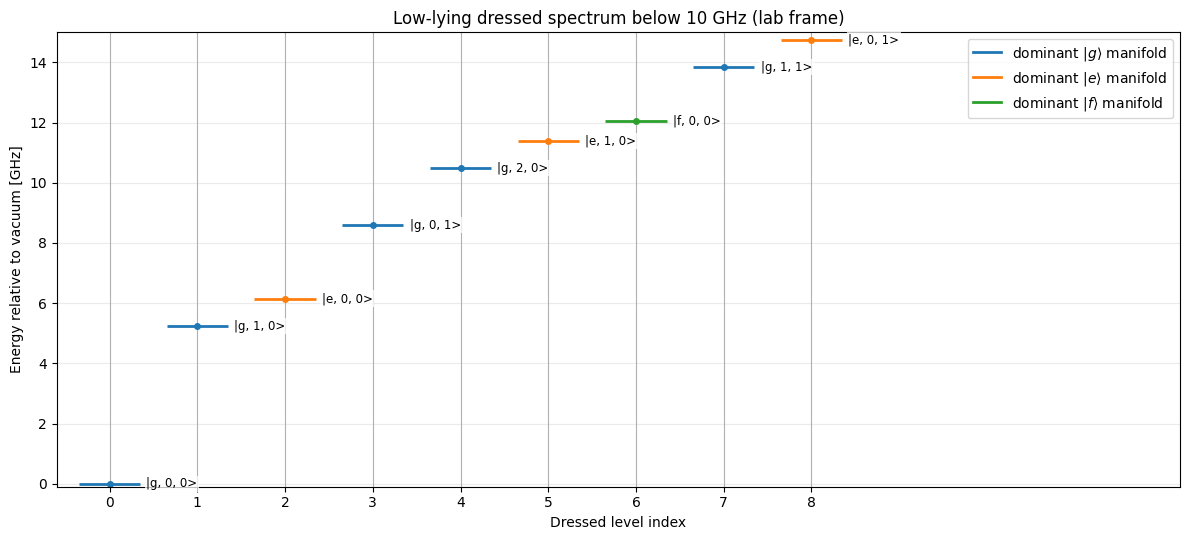

{
  "device_reference_hz": {
    "storage_gf_sideband": 6803533628.0
  },
  "lab_frame_from_levels_hz": {
    "storage_gf_red": 6804115034.441639,
    "readout_gf_red": 3448825278.362842
  },
  "lab_frame_helpers_hz": {
    "storage_gf_red": 6804115034.441636,
    "readout_gf_red": 3448825278.3628397
  },
  "rotating_frame_helpers_hz": {
    "storage_gf_red": -255669694.5244608,
    "readout_gf_red": -255669694.5244608
  }
}


In [7]:
LAB_SPECTRUM = MODEL.energy_spectrum(frame=FrameSpec(), levels=40)
max_energy_ghz = 15
display_levels = [
    level for level in LAB_SPECTRUM.levels if level.energy <= 2.0 * np.pi * 1.0e9 * max_energy_ghz
]
fig = plot_energy_levels(
    LAB_SPECTRUM,
    max_levels=len(display_levels),
    energy_scale=1.0 / (2.0 * np.pi * 1.0e9),
    energy_unit_label="GHz",
    annotate=False,
    title="Low-lying dressed spectrum below 10 GHz (lab frame)",
)
fig.set_size_inches(12.0, 5.5)
ax = fig.axes[0]
for x_pos, level in enumerate(display_levels):
    energy_ghz = level.energy / (2.0 * np.pi * 1.0e9)
    ax.text(
        x_pos + 0.42,
        energy_ghz,
        compact_basis_label(level.dominant_basis_levels),
        va="center",
        ha="left",
        fontsize=8.5,
        bbox={"facecolor": "white", "edgecolor": "none", "alpha": 0.75, "pad": 1.2},
        clip_on=False,
    )
ax.set_xlim(-0.6, len(display_levels) + 3.2)
ax.set_ylim(-0.1, max_energy_ghz)
fig.tight_layout()
plt.show()

storage_lab_delta = LAB_SPECTRUM.find_level("|f,0_storage,0_readout>").energy - LAB_SPECTRUM.find_level("|g,1_storage,0_readout>").energy
readout_lab_delta = LAB_SPECTRUM.find_level("|f,0_storage,0_readout>").energy - LAB_SPECTRUM.find_level("|g,0_storage,1_readout>").energy

transition_summary = {
    "device_reference_hz": {
        "storage_gf_sideband": REFERENCE_FREQUENCIES_HZ["storage_gf_sideband"],
    },
    "lab_frame_from_levels_hz": {
        "storage_gf_red": from_internal_units(storage_lab_delta),
        "readout_gf_red": from_internal_units(readout_lab_delta),
    },
    "lab_frame_helpers_hz": {
        "storage_gf_red": from_internal_units(MODEL.sideband_transition_frequency(mode="storage", storage_level=0, readout_level=0, lower_level=0, upper_level=2)),
        "readout_gf_red": from_internal_units(MODEL.sideband_transition_frequency(mode="readout", storage_level=0, readout_level=0, lower_level=0, upper_level=2)),
    },
    "rotating_frame_helpers_hz": {
        "storage_gf_red": from_internal_units(MODEL.sideband_transition_frequency(mode="storage", storage_level=0, readout_level=0, lower_level=0, upper_level=2, frame=FRAME)),
        "readout_gf_red": from_internal_units(MODEL.sideband_transition_frequency(mode="readout", storage_level=0, readout_level=0, lower_level=0, upper_level=2, frame=FRAME)),
    },
}
save_json(
    "energy_level_summary.json",
    {
        "levels": LAB_SPECTRUM.level_rows(40),
        "transitions": transition_summary,
    },
)
print(json.dumps(transition_summary, indent=2))

## Rotating-Frame Storage-Sideband Spectroscopy

The pulse-level simulator addresses transitions in the selected rotating frame, so the spectroscopy scan below is centered on the current helper `MODEL.sideband_transition_frequency(..., frame=FRAME)` rather than on the historical lab-frame device number.

Scanning a few storage manifolds shows the expected `chi_s`-dependent shift of the effective `|g,n_s+1,0_r> <-> |f,n_s,0_r>` branch.

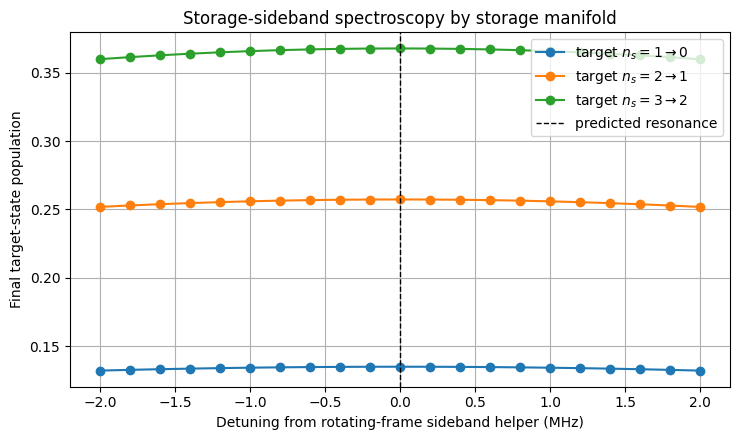

[
  {
    "target_storage_level": 0,
    "predicted_hz": -255669694.5244608,
    "peak_hz": -255669694.5244608,
    "peak_minus_predicted_hz": 0.0
  },
  {
    "target_storage_level": 1,
    "predicted_hz": -261350536.5244608,
    "peak_hz": -261350536.5244608,
    "peak_minus_predicted_hz": 0.0
  },
  {
    "target_storage_level": 2,
    "predicted_hz": -267031378.52446076,
    "peak_hz": -267031378.52446076,
    "peak_minus_predicted_hz": 0.0
  }
]


In [3]:
storage_levels = [0, 1, 2]
frequency_offsets_hz = np.linspace(-2.0e6, 2.0e6, 21)
fig, ax = plt.subplots()
spectroscopy_rows = []

for storage_level in storage_levels:
    predicted_hz, frequencies_hz, response = sideband_frequency_scan(
        mode="storage",
        storage_target_level=storage_level,
        frequency_offsets_hz=frequency_offsets_hz,
        amplitude_hz=1.5e6,
        duration_s=40.0e-9,
    )
    peak_hz = float(frequencies_hz[int(np.argmax(response))])
    spectroscopy_rows.append(
        {
            "target_storage_level": storage_level,
            "predicted_hz": predicted_hz,
            "peak_hz": peak_hz,
            "peak_minus_predicted_hz": peak_hz - predicted_hz,
        }
    )
    ax.plot(
        (frequencies_hz - predicted_hz) / 1.0e6,
        response,
        marker="o",
        label=fr"target $n_s={storage_level + 1}\rightarrow {storage_level}$",
    )

ax.axvline(0.0, color="black", linestyle="--", linewidth=1.0, label="predicted resonance")
ax.set_xlabel("Detuning from rotating-frame sideband helper (MHz)")
ax.set_ylabel("Final target-state population")
ax.set_title("Storage-sideband spectroscopy by storage manifold")
ax.legend()
fig.tight_layout()
plt.show()

save_json("storage_sideband_spectroscopy.json", spectroscopy_rows)
print(json.dumps(spectroscopy_rows, indent=2))

## Coherent Storage-Sideband Transfer

With the sideband centered at the current rotating-frame helper, we can scan the pulse duration and resolve the coherent `|g,1,0_r> <-> |f,0,0_r>` transfer. The peak duration is the effective `pi` time for this branch at the chosen calibration amplitude.

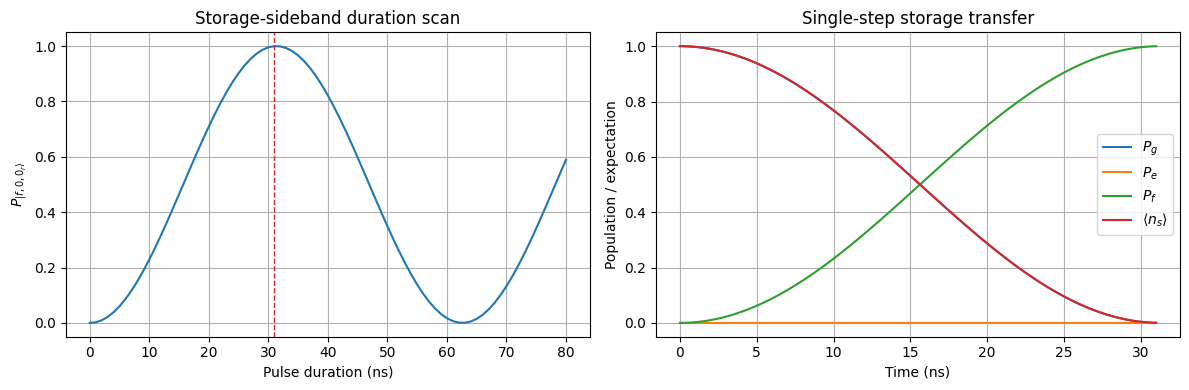

{
  "storage_pi_duration_ns": 31.0,
  "storage_target_population": 0.9997146492715658
}


In [4]:
storage_frequency_rad_s = MODEL.sideband_transition_frequency(
    mode="storage",
    storage_level=0,
    readout_level=0,
    lower_level=0,
    upper_level=2,
    frame=FRAME,
)

durations_s = np.linspace(0.0, 80.0e-9, 81)
storage_duration_response = duration_scan(
    MODEL.basis_state(0, 1, 0),
    drive_target=SidebandDriveSpec(mode="storage", lower_level=0, upper_level=2),
    frequency_rad_s=storage_frequency_rad_s,
    amplitude_hz=CALIBRATION.storage_sideband_rate_hz,
    durations_s=durations_s,
    target_state=MODEL.basis_state(2, 0, 0),
    channel="storage_duration",
)

storage_pi_duration_s = float(durations_s[int(np.argmax(storage_duration_response))])
compiled_storage, storage_transfer = run_drive_pulse(
    MODEL.basis_state(0, 1, 0),
    drive_target=SidebandDriveSpec(mode="storage", lower_level=0, upper_level=2),
    frequency_rad_s=storage_frequency_rad_s,
    amplitude_rad_s=to_internal_units(float(CALIBRATION.storage_sideband_rate_hz)),
    duration_s=storage_pi_duration_s,
    channel="storage_transfer",
    noise=None,
    store_states=True,
)

obs = extract_observables(storage_transfer)
t_ns = compiled_storage.tlist * 1.0e9

fig, axes = plt.subplots(1, 2, figsize=(12.0, 4.0))
axes[0].plot(durations_s * 1.0e9, storage_duration_response, color="tab:blue")
axes[0].axvline(storage_pi_duration_s * 1.0e9, color="tab:red", linestyle="--", linewidth=1.0)
axes[0].set_xlabel("Pulse duration (ns)")
axes[0].set_ylabel(r"$P_{|f,0,0_r\rangle}$")
axes[0].set_title("Storage-sideband duration scan")

axes[1].plot(t_ns, obs["P_g"], label=r"$P_g$")
axes[1].plot(t_ns, obs["P_e"], label=r"$P_e$")
axes[1].plot(t_ns, obs["P_f"], label=r"$P_f$")
axes[1].plot(t_ns, obs["n_s"], label=r"$\langle n_s\rangle$")
axes[1].set_xlabel("Time (ns)")
axes[1].set_ylabel("Population / expectation")
axes[1].set_title("Single-step storage transfer")
axes[1].legend()
fig.tight_layout()
plt.show()

storage_transfer_summary = {
    "storage_pi_duration_ns": storage_pi_duration_s * 1.0e9,
    "storage_target_population": float(np.max(storage_duration_response)),
}
save_json("storage_sideband_transfer.json", storage_transfer_summary)
print(json.dumps(storage_transfer_summary, indent=2))

## Full Sequential Reset

Finally, we run the example-side sequential-reset orchestration on top of the directly constructed core model. The first sweep starts from `|g,N,0_r>` for several storage occupations. The second case starts in the excited transmon manifold and includes the initial `e -> f` preparation pulse before the readout-assisted evacuation stage.

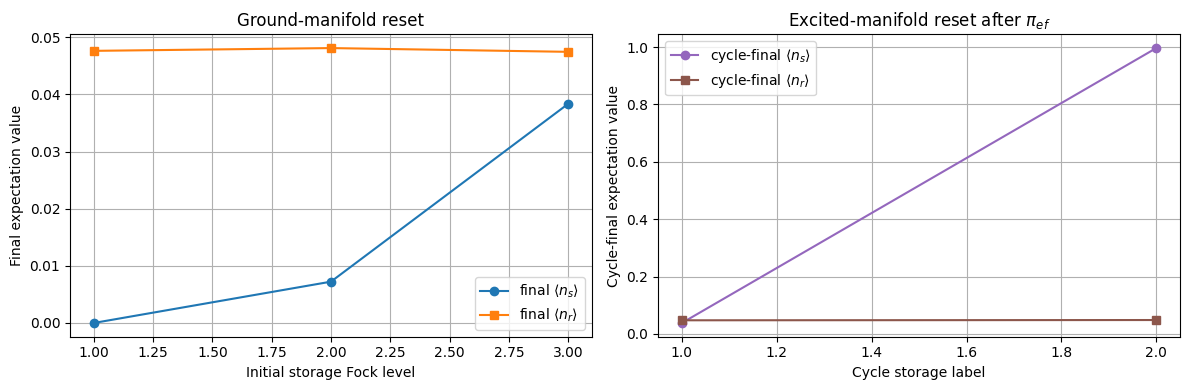

{
  "ground_manifold": {
    "1": {
      "cycle_final_storage": [
        -7.872548692243755e-06
      ],
      "cycle_final_readout": [
        0.047631279279768735
      ],
      "cycle_final_transmon_populations": [
        {
          "0": 0.999528401471676,
          "1": 0.0,
          "2": 0.00047159852832411926
        }
      ]
    },
    "2": {
      "cycle_final_storage": [
        0.997122912924381,
        0.007223874066714263
      ],
      "cycle_final_readout": [
        0.0476141707633187,
        0.0481166450662537
      ],
      "cycle_final_transmon_populations": [
        {
          "0": 0.9993486483056929,
          "1": 0.0,
          "2": 0.0006513516943070187
        },
        {
          "0": 0.9804795452648923,
          "1": 0.0,
          "2": 0.01952045473510769
        }
      ]
    },
    "3": {
      "cycle_final_storage": [
        1.9939484920101593,
        0.9963337794254102,
        0.03835398844733238
      ],
      "cycle_final_readout": [
   

In [5]:
storage_levels = [1, 2, 3]
ground_results = {}
for storage_level in storage_levels:
    ground_results[storage_level] = run_sequential_sideband_reset(
        model=MODEL,
        initial_state=MODEL.basis_state(0, storage_level, 0),
        calibration=CALIBRATION,
        initial_storage_level=storage_level,
        frame=FRAME,
        noise=NOISE,
        pulse_dt_s=PULSE_DT_S,
        ringdown_dt_s=RINGDOWN_DT_S,
    )

ground_final_storage = [float(ground_results[level].cycle_final_storage_photon_number[-1]) for level in storage_levels]
ground_final_readout = [float(ground_results[level].cycle_final_readout_photon_number[-1]) for level in storage_levels]

ef_result = run_sequential_sideband_reset(
    model=MODEL,
    initial_state=MODEL.basis_state(1, 2, 0),
    calibration=CALIBRATION,
    initial_storage_level=2,
    include_initial_ef_prep=True,
    frame=FRAME,
    noise=NOISE,
    pulse_dt_s=PULSE_DT_S,
    ringdown_dt_s=RINGDOWN_DT_S,
)

ef_cycle_storage = [float(value) for value in ef_result.cycle_final_storage_photon_number]
ef_cycle_readout = [float(value) for value in ef_result.cycle_final_readout_photon_number]

fig, axes = plt.subplots(1, 2, figsize=(12.0, 4.0))
axes[0].plot(storage_levels, ground_final_storage, marker="o", label=r"final $\langle n_s\rangle$")
axes[0].plot(storage_levels, ground_final_readout, marker="s", label=r"final $\langle n_r\rangle$")
axes[0].set_xlabel("Initial storage Fock level")
axes[0].set_ylabel("Final expectation value")
axes[0].set_title("Ground-manifold reset")
axes[0].legend()

axes[1].plot([2, 1], ef_cycle_storage, marker="o", label=r"cycle-final $\langle n_s\rangle$", color="tab:purple")
axes[1].plot([2, 1], ef_cycle_readout, marker="s", label=r"cycle-final $\langle n_r\rangle$", color="tab:brown")
axes[1].set_xlabel("Cycle storage label")
axes[1].set_ylabel("Cycle-final expectation value")
axes[1].set_title(r"Excited-manifold reset after $\pi_{ef}$")
axes[1].legend()
fig.tight_layout()
plt.show()

summary = {
    "ground_manifold": {
        str(level): {
            "cycle_final_storage": [float(value) for value in ground_results[level].cycle_final_storage_photon_number],
            "cycle_final_readout": [float(value) for value in ground_results[level].cycle_final_readout_photon_number],
            "cycle_final_transmon_populations": [
                {str(pop_level): float(pop_value) for pop_level, pop_value in cycle.items()}
                for cycle in ground_results[level].cycle_final_transmon_populations
            ],
        }
        for level in storage_levels
    },
    "excited_manifold": {
        "cycle_final_storage": ef_cycle_storage,
        "cycle_final_readout": ef_cycle_readout,
        "cycle_final_transmon_populations": [
            {str(pop_level): float(pop_value) for pop_level, pop_value in cycle.items()}
            for cycle in ef_result.cycle_final_transmon_populations
        ],
    },
}
save_json("sequential_reset_summary.json", summary)
print(json.dumps(summary, indent=2))